# Phase 1d: Finite-EWC response paths

This artifact-only notebook visualizes the completed Plan 10 Phase 1d response surface. It performs no training, data download, Fisher construction, or model fitting.

**Terminology matters.** Phase 1d did not run an adaptive online $\pi_t$ controller, so these are not online controller trajectories. The experiment evaluated the complete action grid at frozen anchors and paces. We show two derived response paths:

- **Profile optimum:** $\arg\min_\pi \widehat{\mathbb E}[R(\pi)]$, the estimand used by the frozen gate.
- **Average batchwise optimum:** the average of the minimizing grid action for each paired four-observation batch. This is descriptive and deliberately exposed as noisy; averaging argmins is not the same as minimizing average risk.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
import numpy as np
import pandas as pd

def find_repo_root() -> Path:
    starts = [Path.cwd()]
    if "__file__" in globals():
        starts.append(Path(__file__).resolve().parent)
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "README.md").is_file() and (candidate / "mnist_experiment").is_dir():
                return candidate
    raise RuntimeError("could not locate repository root")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from mnist_experiment.rotated_mnist.pace_control.artifacts import validate_completed
from mnist_experiment.rotated_mnist.pace_control.response_surface_config import load_response_surface_config

CONFIG_PATH = ROOT / "mnist_experiment/rotated_mnist/pace_control/configs/phase1d_full.json"
config = load_response_surface_config(CONFIG_PATH)
RUN_PATH = (
    ROOT
    / "cache/mnist_experiment/rotated_mnist/plan10/phase1d"
    / config.run_id
)
REQUIRED = (
    "config.json",
    "source_contract.json",
    "prerequisite_contract.json",
    "evaluation_panel.json",
    "anchor_contracts.json",
    "anchor_states.pt",
    "fit_records.json",
    "response_surface.json",
    "gate.json",
    "summary.json",
)
manifest = validate_completed(RUN_PATH, required=REQUIRED)


def load_json(name: str):
    return json.loads((RUN_PATH / name).read_text(encoding="utf-8"))


summary = load_json("summary.json")
gate = load_json("gate.json")
anchor_contracts = load_json("anchor_contracts.json")
response_records = load_json("response_surface.json")
fit_records = load_json("fit_records.json")

assert summary["stage"] == "full"
assert summary["expected_fit_count"] == len(fit_records)
assert summary["failed_fit_count"] == 0

pd.DataFrame(
    [
        ("Immutable run", RUN_PATH.name),
        ("Completed", manifest["completed_at"]),
        ("Paired fits", f"{summary['expected_fit_count']:,}"),
        ("Gate", "PASS" if summary["gate_pass"] else "FAIL"),
        ("Expansion", "recommended" if summary["expansion_recommended"] else "not authorized"),
    ],
    columns=["Field", "Value"],
)


,Field,Value
0,Immutable run,rotated_mnist_plan10_phase1d_full_response_sur...
1,Completed,2026-09-09T02:32:29.063089+00:00
2,Paired fits,"5,376"
3,Gate,FAIL
4,Expansion,not authorized


## Reconstruct the paired response summaries

Every $(\text{anchor}, \text{pace}, \text{replicate})$ unit uses the same four-observation batch across all seven actions. The profile path averages risk before minimizing. The batchwise path minimizes within each paired unit before averaging over its 32 replicate indices.

In [2]:
anchors = pd.DataFrame(anchor_contracts).rename(columns={"step": "anchor_step"})
anchor_meta = anchors[["anchor_step", "angle_degrees", "direction_to_next"]]
surface = pd.DataFrame(response_records).merge(anchor_meta, on=["anchor_step", "direction_to_next"])

risk_rows = []
for record in response_records:
    for pi_text, mean_nll in record["mean_nll_by_pi"].items():
        risk_rows.append(
            {
                "anchor_step": record["anchor_step"],
                "direction_to_next": record["direction_to_next"],
                "pace_degrees": record["pace_degrees"],
                "pi": float(pi_text),
                "mean_nll": mean_nll,
            }
        )
risk = pd.DataFrame(risk_rows)
risk["excess_nll"] = risk["mean_nll"] - risk.groupby(
    ["anchor_step", "pace_degrees"]
)["mean_nll"].transform("min")

fits = pd.DataFrame(fit_records)
successful = fits.loc[fits["failure"].isna()].copy()
unit_columns = ["anchor_step", "direction_to_next", "pace_degrees", "replicate_index"]
batch_optima = (
    successful.sort_values(unit_columns + ["next_nll", "pi"])
    .groupby(unit_columns, as_index=False)
    .first()[unit_columns + ["pi", "next_nll"]]
    .rename(columns={"pi": "optimal_pi"})
)
assert len(batch_optima) == len(config.anchor_steps) * len(config.pace_degrees) * config.replicate_count

profile_path = surface[["anchor_step", "direction_to_next", "pace_degrees", "empirical_best_pi"]].copy()
profile_mean = profile_path.groupby("pace_degrees", as_index=False)["empirical_best_pi"].mean()

# Pair the two anchors in each direction inside a replicate before bootstrapping.
direction_replicates = (
    batch_optima.groupby(["direction_to_next", "pace_degrees", "replicate_index"], as_index=False)
    ["optimal_pi"].mean()
)
rng = np.random.default_rng(101012)
batch_path_rows = []
for (direction, pace), frame in direction_replicates.groupby(["direction_to_next", "pace_degrees"]):
    values = frame.sort_values("replicate_index")["optimal_pi"].to_numpy()
    bootstrap = rng.choice(values, size=(5000, len(values)), replace=True).mean(axis=1)
    batch_path_rows.append(
        {
            "direction_to_next": direction,
            "pace_degrees": pace,
            "mean_optimal_pi": values.mean(),
            "lower": np.quantile(bootstrap, 0.025),
            "upper": np.quantile(bootstrap, 0.975),
        }
    )
batch_path = pd.DataFrame(batch_path_rows)

profile_path.head()


,anchor_step,direction_to_next,pace_degrees,empirical_best_pi
0,20,1,0.000,0.0250
1,20,1,0.375,0.0250
2,20,1,0.750,0.0125
3,20,1,1.125,0.0250
4,20,1,1.500,0.0250


## Two meanings of an average $\pi$ path

The left panel answers the scientific question: which action minimizes estimated expected risk? The right panel is a useful warning about the phrase *average optimal $\pi$*: with only four observations, replicate-level argmins often jump to a grid boundary, and those extremes can average to a value near `.05` even when `.05` is not competitive in expected risk.

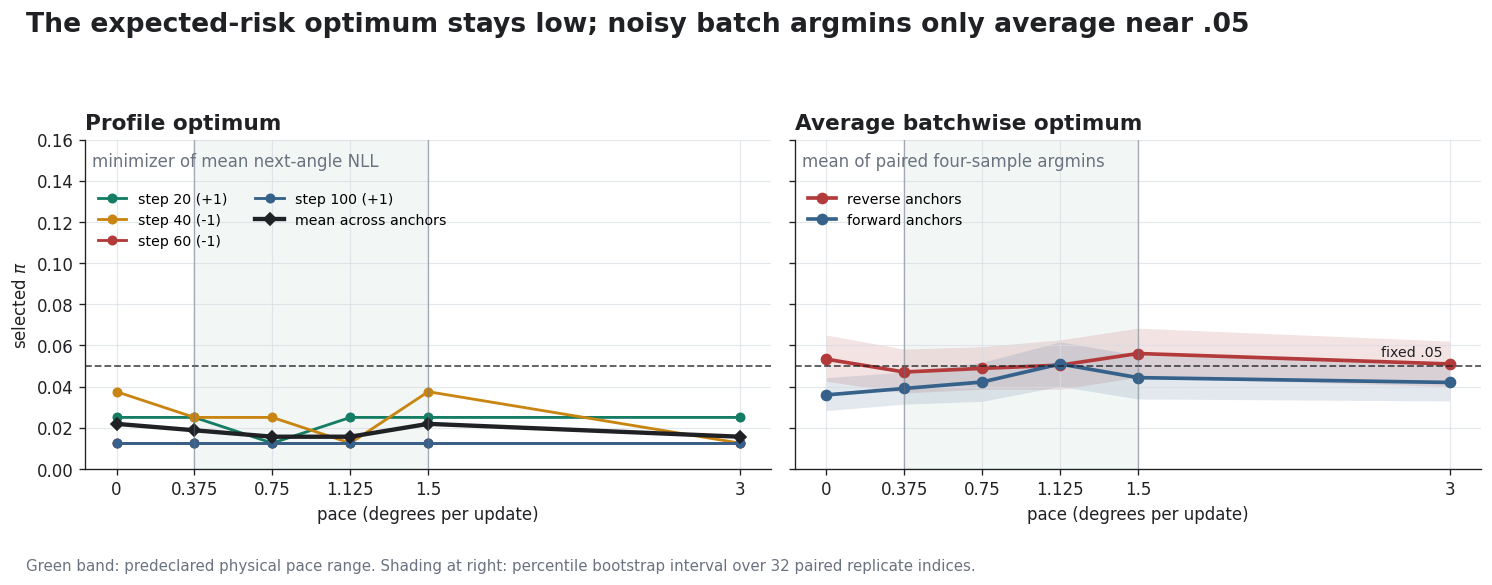

In [3]:
INK = "#202124"
GREEN = "#147D64"
RED = "#B33A3A"
GOLD = "#C98512"
BLUE = "#35618A"
MUTED = "#6B7280"
GRID = "#D9DDE3"
ANCHOR_COLORS = {20: GREEN, 40: GOLD, 60: RED, 100: BLUE}
DIRECTION_COLORS = {-1: RED, 1: BLUE}
DIRECTION_LABELS = {-1: "reverse anchors", 1: "forward anchors"}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": INK,
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.alpha": 0.7,
        "font.size": 10,
        "legend.frameon": False,
        "xtick.color": INK,
        "ytick.color": INK,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), sharex=True, sharey=True)

ax = axes[0]
for anchor_step, frame in profile_path.groupby("anchor_step"):
    direction = int(frame["direction_to_next"].iloc[0])
    frame = frame.sort_values("pace_degrees")
    ax.plot(
        frame["pace_degrees"],
        frame["empirical_best_pi"],
        color=ANCHOR_COLORS[int(anchor_step)],
        marker="o",
        linewidth=1.7,
        markersize=5,
        label=f"step {anchor_step} ({direction:+d})",
    )
ax.plot(
    profile_mean["pace_degrees"],
    profile_mean["empirical_best_pi"],
    color=INK,
    marker="D",
    linewidth=2.6,
    markersize=5.5,
    label="mean across anchors",
)
ax.set_title("Profile optimum", loc="left")
ax.text(0.01, 0.96, "minimizer of mean next-angle NLL", transform=ax.transAxes, va="top", color=MUTED)
ax.legend(ncol=2, loc="upper left", bbox_to_anchor=(0, 0.88), fontsize=8.5)

ax = axes[1]
for direction, frame in batch_path.groupby("direction_to_next"):
    frame = frame.sort_values("pace_degrees")
    color = DIRECTION_COLORS[int(direction)]
    ax.fill_between(frame["pace_degrees"], frame["lower"], frame["upper"], color=color, alpha=0.14, linewidth=0)
    ax.plot(
        frame["pace_degrees"],
        frame["mean_optimal_pi"],
        color=color,
        marker="o",
        linewidth=2.2,
        label=DIRECTION_LABELS[int(direction)],
    )
ax.set_title("Average batchwise optimum", loc="left")
ax.text(0.01, 0.96, "mean of paired four-sample argmins", transform=ax.transAxes, va="top", color=MUTED)
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.88), fontsize=8.5)

for ax in axes:
    ax.axhline(config.fixed_pi, color=INK, linestyle="--", linewidth=1.1, alpha=0.75)
    ax.axvspan(config.physical_pace_minimum, config.physical_pace_maximum, color=GREEN, alpha=0.055, zorder=0)
    ax.axvline(config.physical_pace_minimum, color=MUTED, linewidth=0.8, alpha=0.5)
    ax.axvline(config.physical_pace_maximum, color=MUTED, linewidth=0.8, alpha=0.5)
    ax.set_xticks(config.pace_degrees, [f"{pace:g}" for pace in config.pace_degrees])
    ax.set_ylim(0.0, 0.16)
    ax.set_xlabel("pace (degrees per update)")
axes[0].set_ylabel(r"selected $\pi$")
axes[1].annotate("fixed .05", xy=(3.0, config.fixed_pi), xytext=(-4, 6), textcoords="offset points", ha="right", color=INK, fontsize=8.5)
fig.suptitle("The expected-risk optimum stays low; noisy batch argmins only average near .05", x=0.07, ha="left", fontsize=16, fontweight="bold", color=INK)
fig.text(0.07, 0.01, "Green band: predeclared physical pace range. Shading at right: percentile bootstrap interval over 32 paired replicate indices.", color=MUTED, fontsize=9)
fig.tight_layout(rect=(0.05, 0.06, 1, 0.91))
plt.show()


## Full risk landscape

Each tile reports excess mean next-angle NLL above the best action at the same anchor and pace. Circles mark the column minimum; the dashed row is fixed $\pi=.05$. The `0` and `3.0` degree columns are characterization points outside the predeclared physical range.

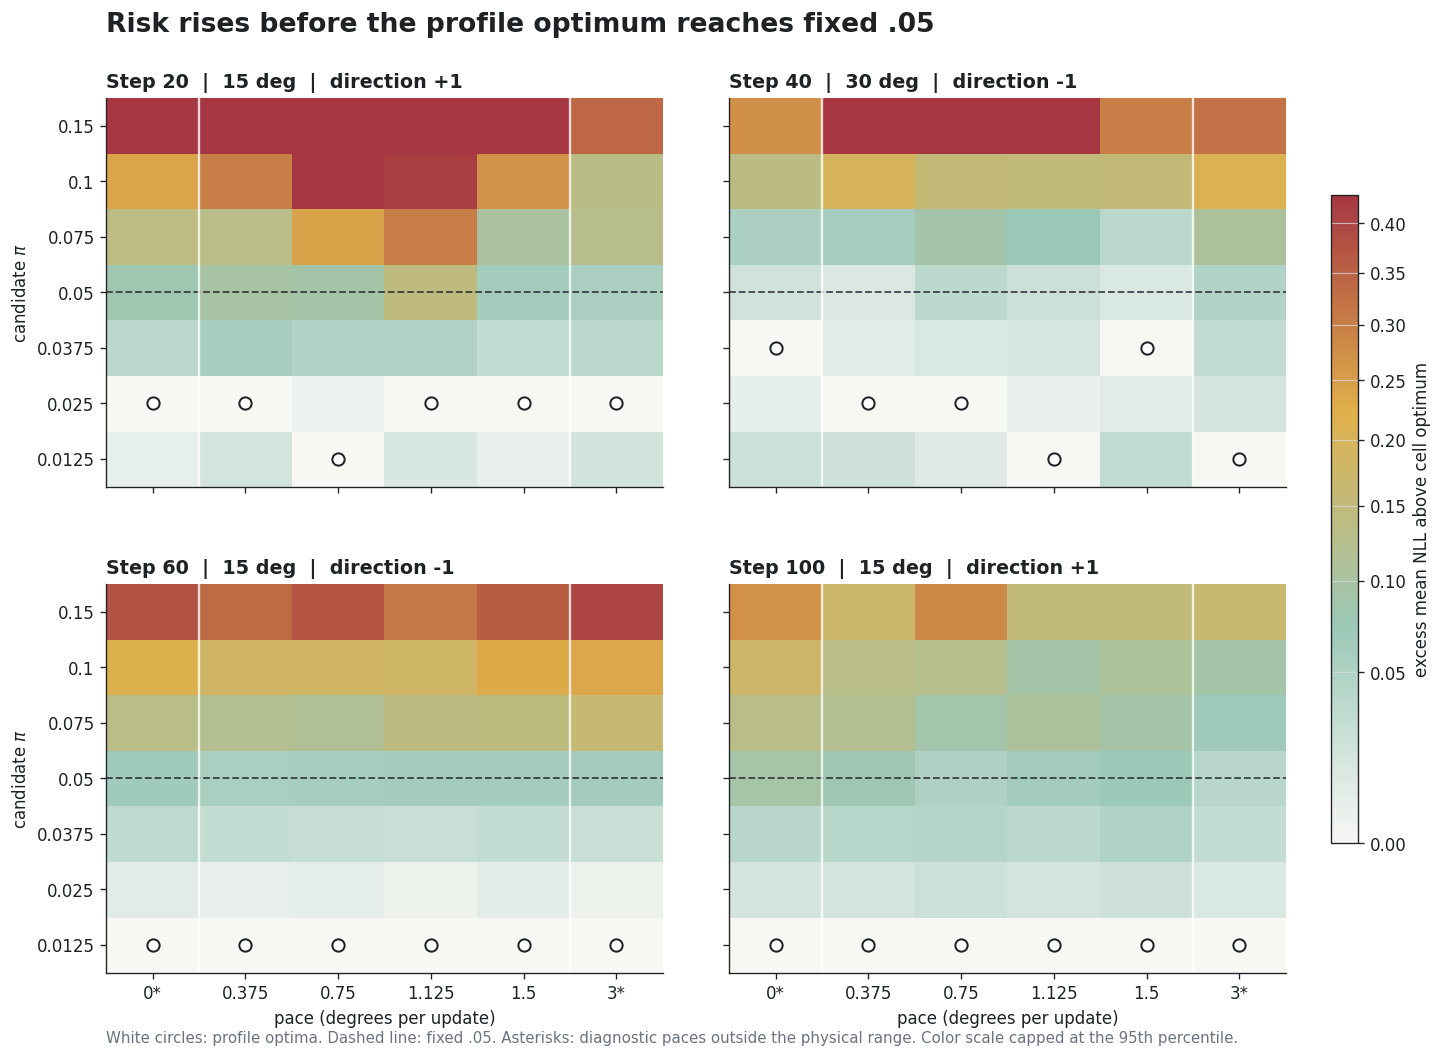

In [4]:
risk_cmap = LinearSegmentedColormap.from_list(
    "phase1d_excess_risk",
    ["#F7F7F4", "#9BC8B8", "#E0B04B", "#A63742"],
)
risk_cap = float(np.quantile(risk["excess_nll"], 0.95))
norm = PowerNorm(gamma=0.62, vmin=0.0, vmax=risk_cap)
pace_values = list(config.pace_degrees)
pi_values = list(config.pi_values)

fig, axes = plt.subplots(2, 2, figsize=(12.6, 9.0), sharex=True, sharey=True)
image_handle = None
for ax, anchor_step in zip(axes.flat, config.anchor_steps):
    frame = risk.loc[risk["anchor_step"] == anchor_step]
    matrix = (
        frame.pivot(index="pi", columns="pace_degrees", values="excess_nll")
        .reindex(index=pi_values, columns=pace_values)
        .to_numpy()
    )
    image_handle = ax.imshow(matrix, origin="lower", aspect="auto", cmap=risk_cmap, norm=norm)
    profile = surface.loc[surface["anchor_step"] == anchor_step].set_index("pace_degrees")
    minimum_rows = [pi_values.index(float(profile.loc[pace, "empirical_best_pi"])) for pace in pace_values]
    ax.scatter(range(len(pace_values)), minimum_rows, s=54, facecolor="white", edgecolor=INK, linewidth=1.2, zorder=3)
    ax.axhline(pi_values.index(config.fixed_pi), color=INK, linestyle="--", linewidth=1.1, alpha=0.8)
    ax.axvline(0.5, color="white", linewidth=1.4, alpha=0.8)
    ax.axvline(4.5, color="white", linewidth=1.4, alpha=0.8)
    meta = anchors.set_index("anchor_step").loc[anchor_step]
    ax.set_title(
        f"Step {anchor_step}  |  {meta['angle_degrees']:.0f} deg  |  direction {int(meta['direction_to_next']):+d}",
        loc="left",
        fontsize=11.5,
    )
    ax.grid(False)

for ax in axes[-1, :]:
    ax.set_xticks(range(len(pace_values)), [f"{pace:g}" + ("*" if pace not in np.arange(0.375, 1.501, 0.375) else "") for pace in pace_values])
    ax.set_xlabel("pace (degrees per update)")
for ax in axes[:, 0]:
    ax.set_yticks(range(len(pi_values)), [f"{pi:g}" for pi in pi_values])
    ax.set_ylabel(r"candidate $\pi$")

fig.suptitle("Risk rises before the profile optimum reaches fixed .05", x=0.08, ha="left", fontsize=16, fontweight="bold", color=INK)
fig.text(0.08, 0.025, "White circles: profile optima. Dashed line: fixed .05. Asterisks: diagnostic paces outside the physical range. Color scale capped at the 95th percentile.", color=MUTED, fontsize=9)
fig.subplots_adjust(left=0.08, right=0.86, bottom=0.09, top=0.9, hspace=0.25, wspace=0.12)
colorbar_axis = fig.add_axes([0.89, 0.21, 0.018, 0.60])
colorbar = fig.colorbar(image_handle, cax=colorbar_axis)
colorbar.set_label("excess mean NLL above cell optimum")
plt.show()


## Decision margins

The left panel puts the fixed action against the predeclared practical margin. The right panel shows the paired crossing contrast $R(.025)-R(.075)$ with simultaneous 95% intervals. A positive contrast would favor the higher action; the required low-to-high reversal never appears.

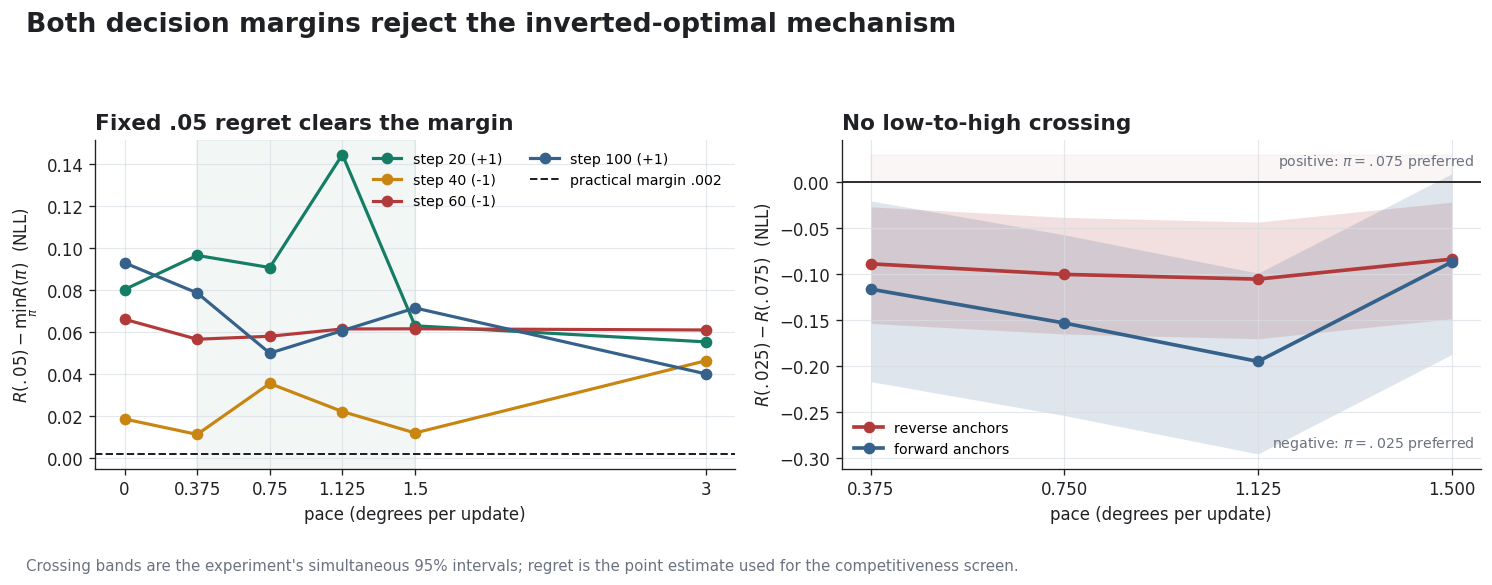

In [5]:
regret = surface[["anchor_step", "direction_to_next", "pace_degrees"]].copy()
regret["fixed_pi_regret"] = [record["regret"]["point_regret"] for record in response_records]

crossing_rows = []
for direction_text, record in gate["crossing_contrasts"].items():
    for pace, mean, lower, upper in zip(
        record["pace_degrees"],
        record["mean"],
        record["simultaneous_lower"],
        record["simultaneous_upper"],
    ):
        crossing_rows.append(
            {
                "direction_to_next": int(direction_text),
                "pace_degrees": pace,
                "mean": mean,
                "lower": lower,
                "upper": upper,
            }
        )
crossing = pd.DataFrame(crossing_rows)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

ax = axes[0]
for anchor_step, frame in regret.groupby("anchor_step"):
    direction = int(frame["direction_to_next"].iloc[0])
    frame = frame.sort_values("pace_degrees")
    ax.plot(
        frame["pace_degrees"],
        frame["fixed_pi_regret"],
        color=ANCHOR_COLORS[int(anchor_step)],
        marker="o",
        linewidth=1.9,
        label=f"step {anchor_step} ({direction:+d})",
    )
ax.axhline(config.practical_nll_margin, color=INK, linestyle="--", linewidth=1.2, label="practical margin .002")
ax.axvspan(config.physical_pace_minimum, config.physical_pace_maximum, color=GREEN, alpha=0.055, zorder=0)
ax.set_xticks(config.pace_degrees, [f"{pace:g}" for pace in config.pace_degrees])
ax.set_xlabel("pace (degrees per update)")
ax.set_ylabel(r"$R(.05)-\min_\pi R(\pi)$  (NLL)")
ax.set_title("Fixed .05 regret clears the margin", loc="left")
ax.legend(ncol=2, fontsize=8.5)

ax = axes[1]
for direction, frame in crossing.groupby("direction_to_next"):
    frame = frame.sort_values("pace_degrees")
    color = DIRECTION_COLORS[int(direction)]
    ax.fill_between(frame["pace_degrees"], frame["lower"], frame["upper"], color=color, alpha=0.16, linewidth=0)
    ax.plot(
        frame["pace_degrees"],
        frame["mean"],
        color=color,
        marker="o",
        linewidth=2.2,
        label=DIRECTION_LABELS[int(direction)],
    )
ax.axhline(0.0, color=INK, linewidth=1.1)
ax.fill_between(
    [config.physical_pace_minimum, config.physical_pace_maximum],
    [0, 0],
    [0.03, 0.03],
    color=RED,
    alpha=0.045,
)
ax.text(0.99, 0.96, r"positive: $\pi=.075$ preferred", transform=ax.transAxes, ha="right", va="top", color=MUTED, fontsize=8.5)
ax.text(0.99, 0.05, r"negative: $\pi=.025$ preferred", transform=ax.transAxes, ha="right", va="bottom", color=MUTED, fontsize=8.5)
ax.set_xticks(crossing["pace_degrees"].unique())
ax.set_xlabel("pace (degrees per update)")
ax.set_ylabel(r"$R(.025)-R(.075)$  (NLL)")
ax.set_title("No low-to-high crossing", loc="left")
ax.legend(fontsize=8.5)

fig.suptitle("Both decision margins reject the inverted-optimal mechanism", x=0.07, ha="left", fontsize=16, fontweight="bold", color=INK)
fig.text(0.07, 0.01, "Crossing bands are the experiment's simultaneous 95% intervals; regret is the point estimate used for the competitiveness screen.", color=MUTED, fontsize=9)
fig.tight_layout(rect=(0.05, 0.06, 1, 0.91))
plt.show()


## Decision

Across the 16 in-bound anchor/pace cells, the profile optimum is `.0125` in 10 cells, `.025` in 5, and `.0375` in 1. It is never `.05` or larger. Fixed `.05` regret ranges from 0.0113 to 0.1447 NLL, well above the 0.002 practical margin, and no anchor is point- or confidence-competitive at an interior pace. The `.025` versus `.075` contrast never reverses in either direction.

The average batchwise argmin can sit near `.05`, but that is a consequence of high-variance four-observation argmins jumping across the diagnostic grid. The paired expected-risk surface is decisive: the current inverted optimal-$\pi$ pace strategy does not produce a crossing through fixed `.05` for this learner. All 5,376 fits succeeded, the frozen gate failed, and the 128-replicate expansion was not authorized.